---
title: "Lecture 17: Runge-Kutta methods"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture17_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# IVP Systems

Most applications involve initial-value problems with multiple unknowns defined by a system of equations.  

. . .

**Predator-prey models** like the one below are commonly studied in ecology:

  \begin{align*}
    \frac{d y}{d t} &= y(1-\alpha y) - \frac{yz}{1+\beta y}, \\
    \frac{d z}{d t} &= -z + \frac{yz}{1+\beta y},
  \end{align*}
where $\alpha$ and $\beta$ are positive constants. Here $y(t)$ represents the prey population and $z(t)$ represents the predator population.

## Vector-valued IVP

We can pack the two dependent variables $y$ and $z$ into a vector-valued function of time, $\mathbf{u}(t)$, as
\begin{align*}
  u_1'(t) &= f_1(t,\mathbf{u}) =  u_1(1-au_1) - \frac{u_1 u_2}{1+bu_1},\\
  u_2'(t) &= f_2(t,\mathbf{u}) = -u_2 + \frac{u_1 u_2}{1+bu_1},
\end{align*}
where $u_1=y$, $u_2=z$.

. . .

::: {.callout-note icon=false}
## Definition: Vector-valued IVP/IVP system
A vector-valued first-order **initial-value problem** (IVP) is
$$\mathbf{u}'(t) = \mathbf{f}\bigl(t,\mathbf{u}(t)\bigr), \qquad a \le t \le b, \qquad
  \mathbf{u}(a)=\mathbf{u}_0,$$
where $\mathbf{u}(t)$ is $m$-dimensional.  If $\mathbf{f}(t,\mathbf{u})=\mathbf{A}(t)\mathbf{u}(t)+ \mathbf{g}(t)$, the differential equation is **linear**; otherwise, it is **nonlinear**.
:::

## Numerical solutions

Generalizing Euler's method to IVP systems is fairly straightforward, 
$$\mathbf{u}_{i+1} = \mathbf{u}_i + h\,\mathbf{f}(t_i,\mathbf{u}_i), \qquad i=0,\cdots,n-1.$$

. . .

This applies Euler's method simultaneously to each component of the ODE system.  

. . .

[We can reuse the code we wrote for last class:]{.content-hidden when-format='revealjs' when-format='pptx'} 

In [12]:
"""
    euler(ivp,n)

Apply Euler's method to solve the given IVP using 'n' time steps.
Returns a vector of times and a vector of solution values.
"""
function euler(ivp,n)
        # Time discretization
        a,b = ivp.tspan
        h = (b-a)/n 
        t = [ a + i*h for i in 0:n ]

        # Initial condition and output setup.
        u = fill(float(ivp.u0),n+1)

        # The time stepping criterion
        for i in 1:n 
            u[i+1] = u[i] + h*ivp.f(u[i],ivp.p,t[i])
        end
        return t,u 
    end

euler

---

In [40]:
# | echo: false

using DifferentialEquations
using Plots
using PrettyTables

In [14]:
function predprey(u,p,t)
    α,β = p      # rename parameters for convenience
    y,z = u      # rename solution components
    s = (y*z) / (1+β*y)     # appears in both equations
    return [ y*(1-α*y) - s, -z + s ]
end;

In [15]:
u₀ = [1,0.01]
tspan = (0.,60.)
α,β = 0.1,0.25

ivp = ODEProblem(predprey,u₀,tspan,[α,β])

ODEProblem with uType Vector{Float64} and tType Float64. In-place: false
timespan: (0.0, 60.0)
u0: 2-element Vector{Float64}:
 1.0
 0.01

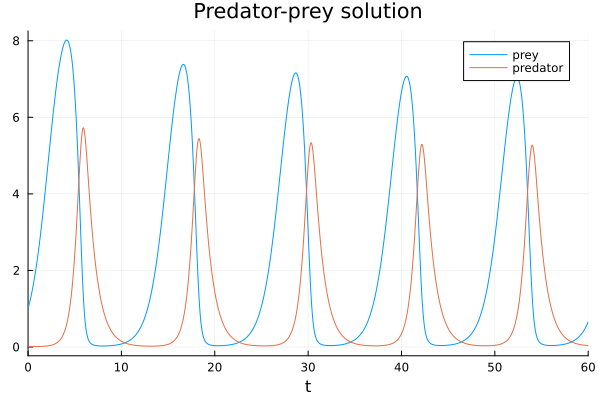

In [16]:
sol = solve(ivp,Tsit5());
plot(sol,label=["prey" "predator"],title="Predator-prey solution")

---

In [17]:
t,u = sol.t,sol.u    # extract times and solution values
@show size(u);
@show t[20];
@show u[20];

size(u) = (100,)
t[20] = 8.386698083051241
u[20] = [0.027739191695661334, 0.699418322938034]


In [18]:
t,u = euler(ivp,1200);

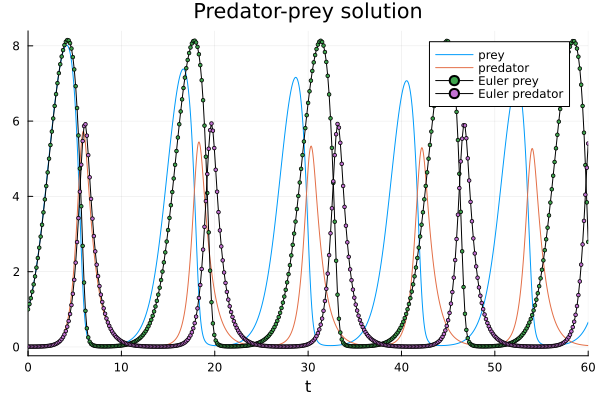

In [19]:
u = [ u[j] for u in u, j in 1:2 ]
plot!(t[1:3:end],u[1:3:end,:],l=(1,:black),m=2,
    label=["Euler prey" "Euler predator"])

. . .

The accuracy of the Euler approximation deteriorates rapidly with $t$.

---

When there are two solutions, we can plot the solution in the *phase plane*.

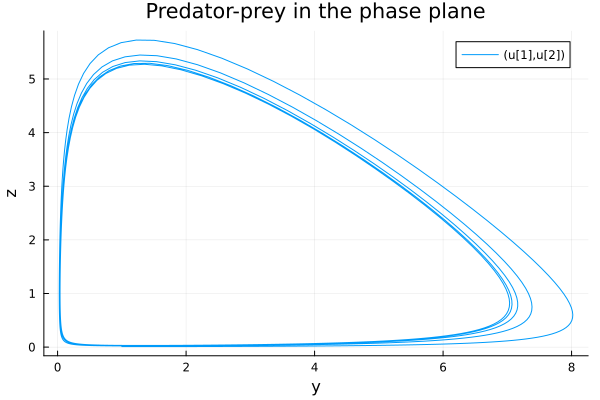

In [20]:
# solution approaches a periodic form
plot(sol,vars=(1,2),title="Predator-prey in the phase plane",
    xlabel="y",ylabel="z")

---

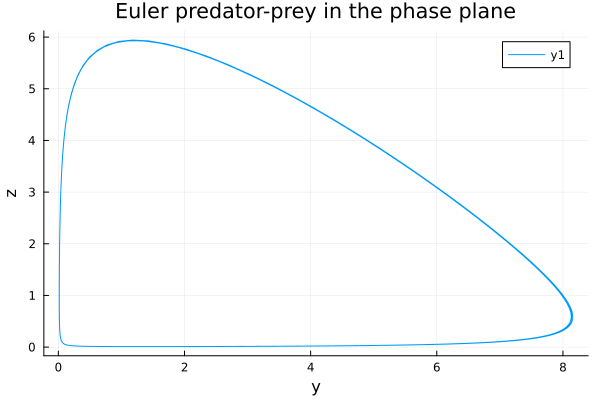

In [23]:
# approximation is approximately periodic, but immediately with wrong period
plot(u[:,1],u[:,2],title="Euler predator-prey in the phase plane",
    xlabel="y",ylabel="z")

## Transformation of high-order systems

First-order ODE systems yields an approach for systems of higher-order as well.

. . .

Two identical pendulums suspended from the same rod and swinging in parallel planes can be modeled as the second-order system
\begin{align*}
  \theta_1''(t) +\gamma \theta_1' + \frac{g}{L} \sin \theta_1 +
  k(\theta_1-\theta_2) &= 0,\\
  \theta_2''(t) +\gamma \theta_2' + \frac{g}{L} \sin \theta_2 +
  k(\theta_2-\theta_1) &= 0,
\end{align*}
where $\theta_1$ and $\theta_2$ are angles made by the two pendulums, $L$ is the length of each pendulum, $\gamma$ is a frictional parameter, and $k$ is a parameter describing a torque produced by the rod when it is twisted. 

. . .

We can convert this problem into a first-order system using the substitutions
$$u_1 = \theta_1, \quad u_2 = \theta_2, \quad u_3 = \theta_1', \quad u_4 = \theta_2'.$$

---

With these definitions the system becomes
\begin{align*}
  u_1' &= u_3, \\
  u_2' &= u_4, \\
  u_3' &= -\gamma u_3 - \frac{g}{L}\sin u_1 + k(u_2-u_1), \\
  u_4' &= -\gamma u_4 - \frac{g}{L}\sin u_2 + k(u_1-u_2),
\end{align*}
which is a first-order system in four dimensions. To complete the description of the problem, you need to specify values for $\theta_1(0)$, $\theta_1'(0)$, $\theta_2(0)$, and $\theta_2'(0)$.

In [24]:
function couple(u,p,t)
    γ,L,k = p
    g = 9.8
    udot = similar(u)
    udot[1:2] .= u[3:4]
    udot[3] = - γ*u[3] - (g/L)*sin(u[1]) + k*(u[2]-u[1])
    udot[4] = - γ*u[4] - (g/L)*sin(u[2]) + k*(u[1]-u[2])
    return udot 
end

u₀ = [1.25,-0.5,0,0]
tspan = (0.,50.);

In [30]:
γ,L,k = 0,0.5,0   # k = 0 => uncoupled
ivp = ODEProblem(couple,u₀,tspan,[γ,L,k])
sol = solve(ivp,Tsit5());

---

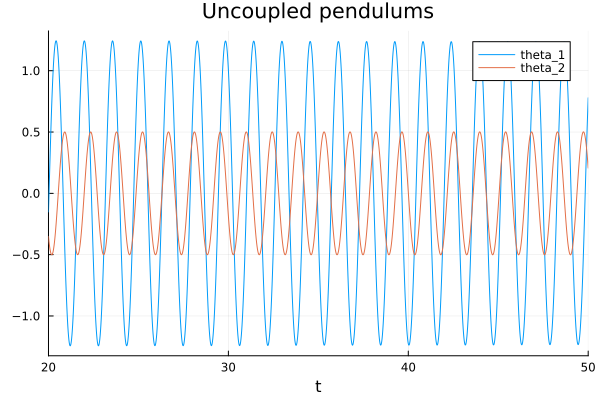

In [29]:
plot(sol,vars=[1,2],label=["theta_1" "theta_2"],
    xlims=[20,50],title="Uncoupled pendulums")

. . .

The pendulums swing independently and have different periods of oscillation, passing in and out of phase with one another.

---

With coupling, we see the pendulums in phase as they are passing energy back and forth.

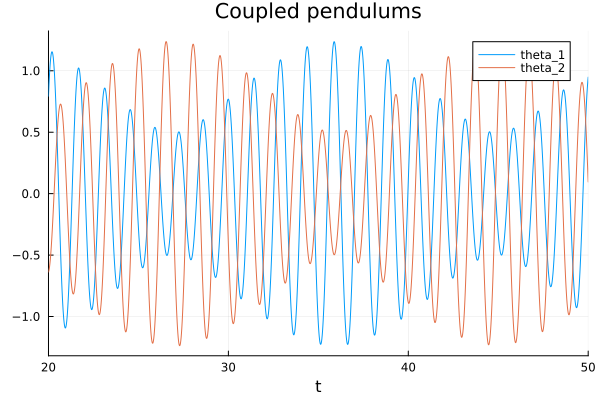

In [32]:
k = 1  # k=1 => coupled
ivp = ODEProblem(couple,u₀,tspan,[γ,L,k])
sol = solve(ivp,Tsit5())
plot(sol,vars=[1,2],label=["theta_1" "theta_2"],
    xlims=[20,50],title="Coupled pendulums")

# Runge-Kutta methods

One of the most popular types of methods for IVP systems are **Runge-Kutta methods**.  These are one-step methods and boost accuracy past first-order by evaluating the ODE function $f(t,u)$ more than once per step.

## A second-order method

Consider a series expansion of the exact solution to $u'=f(t,u)$,
$$\hat{u}(t_{i+1}) = \hat{u}(t_i) + h \hat{u}'(t_i) + \frac{1}{2}h^2 \hat{u}''(t_i) + O(h^3).$$


. . .

If we replace $\hat{u}'$ by $f$ and keep only the first two terms on the right-hand side, we would obtain the Euler method. To get more accuracy we will need to compute or estimate the third term as well. 

. . .

Note that
$$\hat{u}'' = f' = \frac{d f}{d t} = \frac{\partial f}{\partial t} + \frac{\partial f}{\partial u} \frac{d u}{d t} = f_t + f_u f,$$
where we have applied the multidimensional chain rule to the derivative, because both of the arguments of $f$ depend on $t$.

---

Using this expression, we obtain
  $$\hat{u}(t_{i+1}) = \hat{u}(t_i) + h\left[f\bigl(t_i,\hat{u}(t_i)\bigr) +
    \frac{h}{2}f_t\bigl(t_i,\hat{u}(t_i)\bigr) +
    \frac{h}{2}f\bigl(t_i,\hat{u}(t_i)\bigr)\,f_u\bigl(t_i,\hat{u}(t_i)\bigr)\right] + O(h^3).$$

. . .

We have no desire to calculate and then code those partial derivatives of $f$ directly; an approximate approximation is called for. Observe that
$$
  f\bigl(t_i+\alpha,\hat{u}(t_i)+\beta\bigr) = f\bigl(t_i,\hat{u}(t_i)\bigr) +
  \alpha f_t\bigl(t_i,\hat{u}(t_i)\bigr) + \beta f_u\bigl(t_i,\hat{u}(t_i)\bigr) +
  O\bigl(\alpha^2 + |\alpha\beta| + \beta^2\bigr).$$

. . .

Matching this expression to the term in brackets above, it seems natural to select $\alpha = h/2$ and $\beta = \frac{1}{2}h f\bigl(t_i,\hat{u}(t_i)\bigr)$. Doing so, we find
  $$\hat{u}(t_{i+1}) = \hat{u}(t_i) + h\left[f\bigl(t_i+\alpha,\hat{u}(t_i)+\beta\bigr)\right] +
  O(h\alpha^2 + h|\alpha \beta| + h\beta^2 + h^3).$$

. . .

Truncation of the series here results in a new one-step method.

---

::: {.callout-note icon=false}
## Definition: Improved Euler method (IE2)
The improved Euler method is the one-step formula
$${u}_{i+1} = u_i +  hf\left(t_i+\tfrac{1}{2}h,u_i+\tfrac{1}{2}h f(t_i,u_i)\right).$$
:::

. . .

Note that we must evaluate $f$ twice, but the omitted terms are now of size 
$$O(h\alpha^2 + h|\alpha \beta| + h\beta^2 + h^3) = O(h^3).$$

. . .

Therefore $h\tau_{i+1}=O(h^3)$, and the order of accuracy of improved Euler is two.

## Implementation

Runge–Kutta methods are called *multistage* methods. In the first stage, the method takes an Euler half-step to time $t_i+\frac{1}{2}h$:

\begin{align*}
  k_1 &= h f(t_i,u_i), \\
  v &= u_i + \tfrac{1}{2}k_1.
\end{align*}

. . .

The second stage employs an Euler-style strategy over the whole time step, but using the value from the first stage to get the slope:

\begin{align*}
  k_2 &= h f\left(t_i+\tfrac{1}{2}h,v\right),\\
  {u}_{i+1} &= u_i + k_2.
\end{align*}

---

In [33]:
"""
    ie2(ivp,n)

Apply the Improved Euler method to solve the given IVP using `n`
time steps. Returns a vector of times and a vector of solution
values.
"""
function ie2(ivp,n)
    # Time discretization.
    a,b = ivp.tspan
    h = (b-a)/n
    t = [ a + i*h for i in 0:n ]

    # Initialize output.
    u = fill(float(ivp.u0),n+1)

    # Time stepping.
    for i in 1:n
        uhalf = u[i] + h/2*ivp.f(u[i],ivp.p,t[i]);
        u[i+1] = u[i] + h*ivp.f(uhalf,ivp.p,t[i]+h/2);
    end
    return t,u
end

ie2

## Other Runge-Kutta methods

Using the Taylor series derivation, one can derive other methods of even higher orders of accuracy.  Doing so requires extra stages, and the algebra grows rapidly in complexity.  We won't go into details regarding this derivation.

. . .

A generic $s$-stage RK method takes the form

  \begin{align*}
    k_1 &= h f(t_i,u_i),\\
    k_2 &= h f(t_i+c_1h,u_i + a_{11}k_1),\\
    k_3 &= h f(t_i+c_2h, u_i + a_{21}k_1 + a_{22}k_2),\\
    &\vdots\\
    k_s &= h f(t_i + c_{s-1}h, u_i + a_{s-1,1}k_1 + \cdots +
    a_{s-1,s-1}k_{s-1}),\\
    u_{i+1} &= u_i + b_1k_1 + \cdots + b_s k_s.
  \end{align*}

---

This recipe is completely determined by the number of stages $s$ and the constants $a_{ij}$, $b_j$, and $c_i$.  Often an RK method is presented as just a table of these numbers, as in

  $$\begin{array}{r|ccccc}
    0 &  &  & & & \\
    c_1 & a_{11} & & &\\
    c_2 & a_{21} & a_{22} & & &\\
    \vdots & \vdots & & \ddots & &\\
    c_{s-1} & a_{s-1,1} & \cdots & & a_{s-1,s-1}&\\[1mm] \hline
    \rule{0pt}{2.25ex}    & b_1 & b_2 & \cdots & b_{s-1} & b_s
  \end{array}$$

. . .

For example, IE2 is given by

  $$\begin{array}{r|cc}
    \rule{0pt}{2.75ex}0 &  &  \\
    \rule{0pt}{2.75ex}\frac{1}{2} & \frac{1}{2} &\\[1mm] \hline
    \rule{0pt}{2.75ex}& 0 & 1
  \end{array}$$

---

Here are two more two-stage, second-order methods, **modified Euler** and **Heun's method**, respectively:

  $$\begin{array}{r|cc}
    \rule{0pt}{2.75ex}0 &  &  \\
    \rule{0pt}{2.75ex}1 & 1 &\\[1mm] \hline
    \rule{0pt}{2.75ex}& \frac{1}{2} & \frac{1}{2}
  \end{array}\quad\quad 
  \begin{array}{r|cc}
   \rule{0pt}{2.75ex} 0 &  &  \\
   \rule{0pt}{2.75ex} \frac{2}{3} & \frac{2}{3} &\\[1mm] \hline
   \rule{0pt}{2.75ex} & \frac{1}{4} & \frac{3}{4}
  \end{array}$$

. . .

::: {.callout-warning icon=false}
## Fact: 
Euler, improved Euler (IE2), and modified Euler (ME2) are all distinct numerical methods.
:::

## Fourth-order Runge-Kutta

The most commonly used RK method, and perhaps the most popular IVP method of all, is the fourth-order one given by

  $$\begin{array}{r|cccc}
    \rule{0pt}{2.75ex}0 &  & & & \\
    \rule{0pt}{2.75ex}\frac{1}{2} & \frac{1}{2} & & &\\
    \rule{0pt}{2.75ex}\frac{1}{2} & 0 & \frac{1}{2} & &\\
    \rule{0pt}{2.75ex}1 & 0 & 0 & 1\\[1mm] \hline
    \rule{0pt}{2.75ex}& \frac{1}{6} & \frac{1}{3} & \frac{1}{3} & \frac{1}{6}
  \end{array}$$

. . .

This formula is often referred to as *the* fourth-order RK method, even though there are many others, and we refer to it as **RK4**.  

---

::: {.callout-note icon=false}
## Definition: Fourth-order Runge–Kutta method (RK4)

\begin{align*}
    k_1 &= hf(t_i,u_i), &k_2 = hf(t_i+h/2,u_i+k_1/2),\\
    k_3 &= hf(t_i+h/2,u_i+k_2/2), &k_4 = hf(t_i+h,u_i+k_3),\\
    u_{i+1} &= u_i + k_1/6 + k_2/3 + k_3/3 + k_4/6.&
  \end{align*}
:::

In [34]:
"""
    rk4(ivp,n)
Apply the common Runge-Kutta 4th order method to solve the given 
IVP using `n` time steps. Returns a vector of times and a vector of solution values.
"""
function rk4(ivp,n)
    # Time discretization.
    a,b = ivp.tspan
    h = (b-a)/n
    t = [ a + i*h for i in 0:n ]

    # Initialize output.
    u = fill(float(ivp.u0),n+1)

    # Time stepping.
    for i in 1:n
        k₁ = h*ivp.f( u[i],      ivp.p, t[i]     )
        k₂ = h*ivp.f( u[i]+k₁/2, ivp.p, t[i]+h/2 )
        k₃ = h*ivp.f( u[i]+k₂/2, ivp.p, t[i]+h/2 )
        k₄ = h*ivp.f( u[i]+k₃,   ivp.p, t[i]+h   )
        u[i+1] = u[i] + (k₁ + 2(k₂+k₃) + k₄)/6
    end
    return t,u
end

rk4

---

In [36]:
f = (u,p,t) -> sin((t+u)^2)
tspan = (0.0,4.0)
u₀ = -1.0

ivp = ODEProblem(f,u₀,tspan)
u_ref = solve(ivp,Tsit5(),reltol=1e-14,abstol=1e-14);

In [41]:
n = [ round(Int,2*10^k) for k in 0:0.5:3 ]
err_IE2,err_RK4 = [],[]
for n in n
    t,u = ie2(ivp,n)
    push!( err_IE2, maximum( @.abs(u_ref(t)-u) ) )
    t,u = rk4(ivp,n)
    push!( err_RK4, maximum( @.abs(u_ref(t)-u) ) )
end

pretty_table([n err_IE2 err_RK4], header=["n","IE2 error","RK4 error"])

┌──────┬─────────────┬─────────────┐
│    n │   IE2 error │   RK4 error │
├──────┼─────────────┼─────────────┤
│    2 │     1.76903 │    0.820651 │
│    6 │    0.512684 │    0.791925 │
│   20 │   0.0240594 │  0.00081269 │
│   63 │  0.00225327 │  8.06216e-6 │
│  200 │ 0.000222419 │  7.60655e-8 │
│  632 │  2.22528e-5 │   7.513e-10 │
│ 2000 │  2.22177e-6 │ 7.45187e-12 │
└──────┴─────────────┴─────────────┘


---

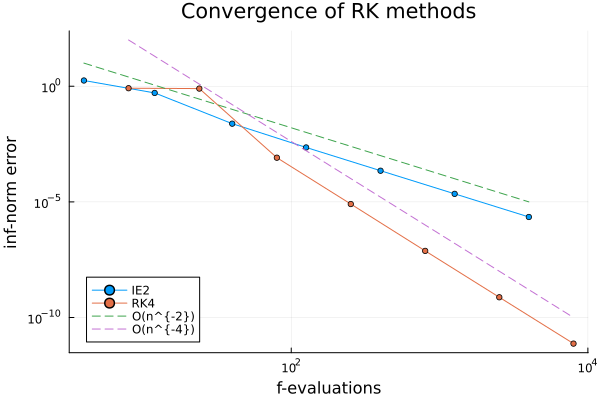

In [43]:
plot([2n 4n],[err_IE2 err_RK4],m=3,label=["IE2" "RK4"],
    xaxis=(:log10,"f-evaluations"),yaxis=(:log10,"inf-norm error"),
    title="Convergence of RK methods",leg=:bottomleft)

plot!(2n,1e-5*(n/n[end]).^(-2),l=:dash,label="O(n^{-2})")
plot!(4n,1e-10*(n/n[end]).^(-4),l=:dash,label="O(n^{-4})")